# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


Todas as colunas estão com o tipo de dado correto.

In [7]:
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

Não foi identificado nenhum valor nulo no dataframe.

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [24]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


### Valor Aluguel

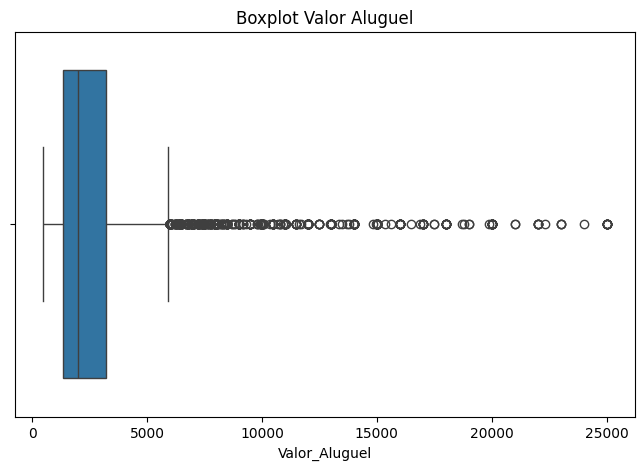

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Valor_Aluguel'])
plt.title('Boxplot Valor Aluguel')
plt.show()

In [29]:
Q1= df['Valor_Aluguel'].quantile(0.25)
Q3 = df['Valor_Aluguel'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-1425.0
5975.0


In [31]:
df = df[df['Valor_Aluguel'] <= limite_superior]

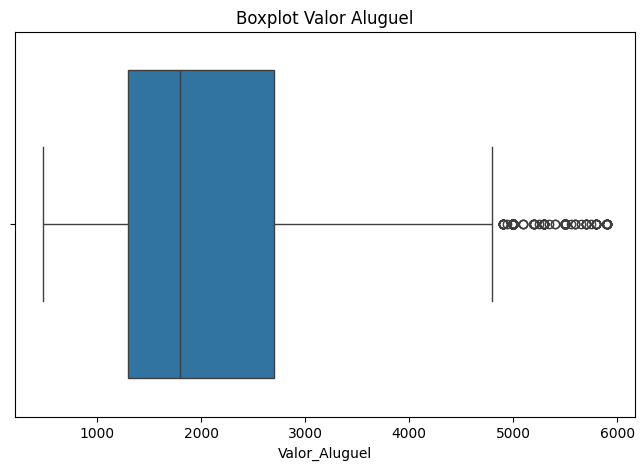

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Valor_Aluguel'])
plt.title('Boxplot Valor Aluguel')
plt.show()

O boxplot da variável Valor_Aluguel evidenciou inicialmente uma grande quantidade de valores extremos acima de aproximadamente 6 mil reais, chegando até 25 mil reais. Como esses valores poderiam distorcer o modelo de regressão e representam uma pequena parcela da base, foi utilizado o método IQR para identificar e remover os outliers. Após o tratamento, observou-se uma distribuição mais equilibrada, mantendo apenas valores considerados plausíveis para análise.

### Valor Condomínio

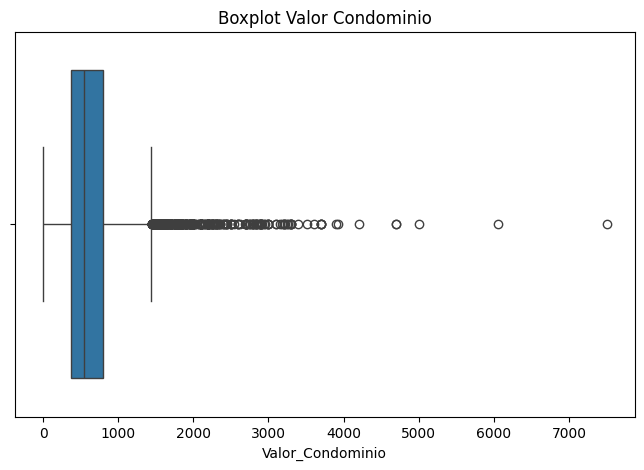

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Valor_Condominio'])
plt.title('Boxplot Valor Condominio')
plt.show()

### Metragem

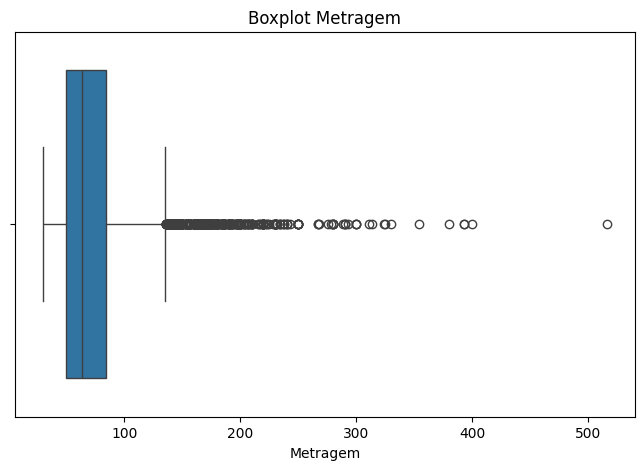

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Metragem'])
plt.title('Boxplot Metragem')
plt.show()

In [42]:
df[df['Metragem'] > 600]

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas


Após o tratamento dos outliers da variável Valor_Aluguel, foi realizada a análise das variáveis Metragem e Valor_Condominio. Observou-se que os valores extremamente altos de metragem, próximos de 900 m², já haviam sido removidos indiretamente, restando imóveis com metragem máxima próxima de 520 m². Em relação ao valor de condomínio, ainda permanecem alguns valores elevados, chegando a aproximadamente 7.500 reais. No entanto, esses casos podem representar imóveis de alto padrão, com maior infraestrutura e serviços agregados. Dessa forma, optou-se por manter os registros dessas duas variáveis, preservando informações relevantes para o modelo e evitando a remoção de dados potencialmente válidos.

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




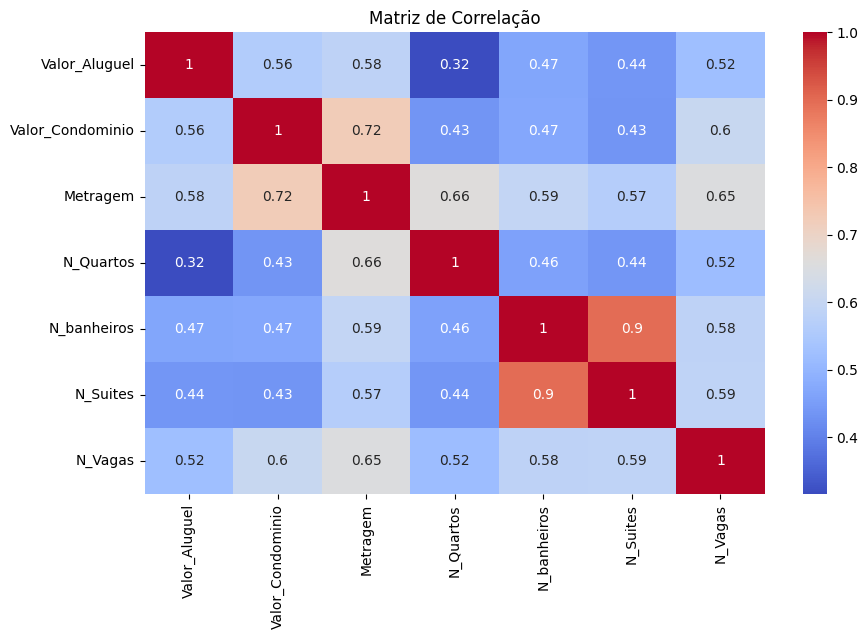

In [46]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação mostrou que a variável Metragem apresentou a correlação mais forte com Valor_Aluguel (0.58), indicando que imóveis maiores tendem a possuir aluguéis mais altos. Em seguida, Valor_Condominio (0.56) e N_Vagas (0.52) também apresentaram correlação positiva relevante, demonstrando influência no valor final do aluguel. Já a variável N_Quartos apresentou a menor correlação (0.32), sugerindo menor impacto isolado no modelo. Além disso, observou-se uma correlação muito alta entre N_banheiros e N_Suites (0.90), o que pode indicar multicolinearidade entre essas variáveis.


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [50]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X treino:", X_train.shape)
print("X teste:", X_test.shape)
print("y treino:", y_train.shape)
print("y teste:", y_test.shape)

X treino: (5163, 6)
X teste: (1291, 6)
y treino: (5163,)
y teste: (1291,)


In [60]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)

Após separar as variáveis independentes (X) e a variável dependente (y), os dados foram divididos em treino e teste utilizando a função train_test_split(). Foram utilizados 80% dos dados para treinar o modelo e 20% para testá-lo, permitindo avaliar o desempenho do modelo em dados que ele ainda não viu.

B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [62]:
modelo = LinearRegression() #cria o modelo de regressão

In [89]:
modelo.fit(X, y) # treina o modelo

LinearRegression()

In [91]:
modelo.intercept_

907.9542975819488

In [93]:
modelo.coef_

array([16.4867985])

#### Nossa equação seria:  Valor_Aluguel=907.95+16.49(Metragem)
O intercepto encontrado foi de aproximadamente 907,95, representando o valor inicial estimado do aluguel quando a metragem é igual a zero (situação apenas teórica). Já o coeficiente foi de aproximadamente 16,49, indicando que a cada aumento de 1 metro quadrado no imóvel, o valor do aluguel tende a aumentar cerca de 16,49 reais. Isso demonstra uma relação positiva entre metragem e valor do aluguel.

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [97]:
previsao_treino = modelo.predict(X) # faz previsões de treino

In [99]:
from sklearn.metrics import r2_score

In [101]:
r2_treino = r2_score(y_train, previsao_treino)
print(r2_treino)

0.337893376161131


O modelo apresentou um R² de aproximadamente 0,338, indicando que cerca de 33,8% da variação do valor do aluguel pode ser explicada apenas pela variável Metragem. Esse resultado mostra que existe uma relação entre o tamanho do imóvel e o valor do aluguel, porém a metragem sozinha não é suficiente para explicar totalmente os preços, já que outras variáveis também influenciam esse valor. Para previsões mais precisas, seria interessante utilizar um modelo com mais variáveis explicativas.

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

In [104]:
# calcula valores previstos com base na metragem
previsao_treino = modelo.predict(X)

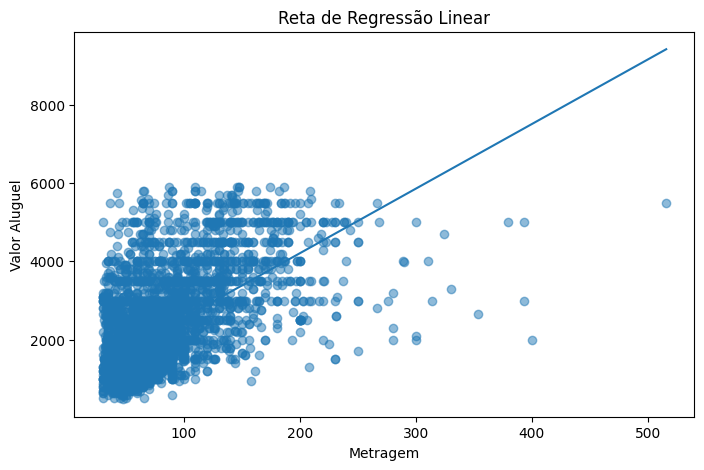

In [108]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, alpha=0.5)

X_ordenado = X.sort_values(by='Metragem')

plt.plot(
    X_ordenado,
    modelo.predict(X_ordenado)
)

plt.xlabel("Metragem")
plt.ylabel("Valor Aluguel")
plt.title("Reta de Regressão Linear")

plt.show()

O gráfico da regressão linear mostrou uma relação positiva entre metragem e valor do aluguel, indicando que imóveis maiores tendem a apresentar preços mais elevados. No entanto, observa-se uma dispersão significativa dos pontos ao redor da reta, principalmente entre imóveis de menor e média metragem. Isso demonstra que, embora a metragem seja uma variável relevante, ela não é suficiente para explicar completamente o valor do aluguel, sendo necessário considerar outras variáveis para melhorar a precisão do modelo.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [111]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

In [115]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = modelo.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = modelo.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.35007442949598344


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

Escreva sua resposta aqui.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [ ]:
#seu código aqui

B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [ ]:
#seu código aqui

C) Traga o valor do R quadrado e avalie o valor encontrado.

In [ ]:
#seu código aqui

0.6072329037304596

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [ ]:
#seu código aqui

Coeficiente de Determinação (R²) nos Dados de Teste: 0.6327633459161506


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

Digite sua resposta aqui